In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import accuracy_score

In [2]:
np.random.seed(42)

num_passengers = 1000

data = pd.DataFrame({

    "Age": np.random.randint(18, 80, num_passengers),

    "Walking_Speed": np.random.uniform(0.5, 2.0, num_passengers),

    "Panic_Level": np.random.randint(1, 10, num_passengers),

    "Seat_Row": np.random.randint(1, 30, num_passengers),

    "Exit_Distance": np.random.randint(1, 25, num_passengers)

})

# Generate evacuation time
data["Evacuation_Time"] = (

    data["Exit_Distance"] * 2 +

    data["Panic_Level"] * 3 +

    (80 - data["Walking_Speed"] * 20)

)

print(data.head())

   Age  Walking_Speed  Panic_Level  Seat_Row  Exit_Distance  Evacuation_Time
0   56       1.065108            3         3             18       103.697831
1   69       1.624367            4        13              5        69.512651
2   46       1.089484            5        23             16       105.210317
3   32       1.743746            6         9             19       101.125073
4   60       1.353622            3        21             14        89.927556


In [3]:
data.to_csv("evacuation_dataset.csv", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


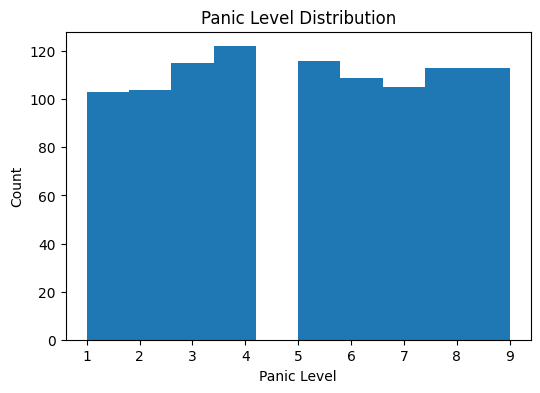

In [4]:
plt.figure(figsize=(6,4))

plt.hist(data["Panic_Level"])

plt.title("Panic Level Distribution")

plt.xlabel("Panic Level")

plt.ylabel("Count")

plt.show()

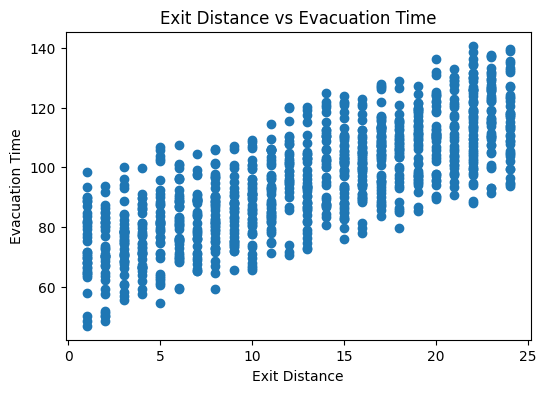

In [5]:
plt.figure(figsize=(6,4))

plt.scatter(data["Exit_Distance"], data["Evacuation_Time"])

plt.xlabel("Exit Distance")

plt.ylabel("Evacuation Time")

plt.title("Exit Distance vs Evacuation Time")

plt.show()

In [6]:
X = data[[
    "Age",
    "Walking_Speed",
    "Panic_Level",
    "Seat_Row",
    "Exit_Distance"
]]

y = data["Evacuation_Time"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
model = RandomForestRegressor()

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [9]:
predictions = model.predict(X_test)

print(predictions[:10])

[ 82.08589731 105.51046992 109.32165825  99.86834414  96.15145481
 109.54344238  78.72755255 107.44033786 102.89133443  91.50527947]


In [10]:
mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 1.5916402232215217


In [11]:
data["Congestion"] = np.where(

    data["Exit_Distance"] > 15,
    1,
    0
)

print(data.head())

   Age  Walking_Speed  Panic_Level  Seat_Row  Exit_Distance  Evacuation_Time  \
0   56       1.065108            3         3             18       103.697831   
1   69       1.624367            4        13              5        69.512651   
2   46       1.089484            5        23             16       105.210317   
3   32       1.743746            6         9             19       101.125073   
4   60       1.353622            3        21             14        89.927556   

   Congestion  
0           1  
1           0  
2           1  
3           1  
4           0  


In [12]:
X2 = data[[
    "Age",
    "Walking_Speed",
    "Panic_Level",
    "Seat_Row",
    "Exit_Distance"
]]

y2 = data["Congestion"]

In [13]:
X2_train, X2_test, y2_train, y2_test = train_test_split(

    X2,
    y2,
    test_size=0.2,
    random_state=42
)

In [14]:
classifier = RandomForestClassifier()

classifier.fit(X2_train, y2_train)

print("Congestion Model Ready")

Congestion Model Ready


In [15]:
congestion_pred = classifier.predict(X2_test)

accuracy = accuracy_score(y2_test, congestion_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [16]:
exits = {

    "Front Exit": 5,
    "Middle Exit": 12,
    "Rear Exit": 20
}

best_exit = min(exits, key=exits.get)

print("Best Exit:", best_exit)

Best Exit: Front Exit


In [17]:
layouts = {

    "Layout A": 120,
    "Layout B": 95,
    "Layout C": 80
}

best_layout = min(layouts, key=layouts.get)

print("Optimized Cabin Layout:", best_layout)

Optimized Cabin Layout: Layout C


In [18]:
data["Safety_Score"] = (

    100 -

    (data["Panic_Level"] * 3) -

    (data["Exit_Distance"] * 1.5)

)

print(data[[
    "Panic_Level",
    "Exit_Distance",
    "Safety_Score"
]].head())

   Panic_Level  Exit_Distance  Safety_Score
0            3             18          64.0
1            4              5          80.5
2            5             16          61.0
3            6             19          53.5
4            3             14          70.0


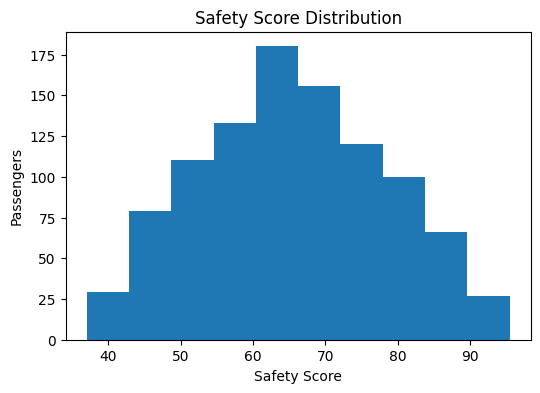

In [19]:
plt.figure(figsize=(6,4))

plt.hist(data["Safety_Score"])

plt.title("Safety Score Distribution")

plt.xlabel("Safety Score")

plt.ylabel("Passengers")

plt.show()

In [20]:
new_passenger = [[

    65,     # age
    0.7,    # speed
    8,      # panic
    25,     # row
    20      # distance

]]

predicted_time = model.predict(new_passenger)

print("Predicted Evacuation Time:", predicted_time)

Predicted Evacuation Time: [129.19507335]


C:\Users\poula\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
